# Loan Approval Risk Modeling
### FinTech Innovations, Risk Analytics Team

## Overview

A gradient boosting classifier predicts loan approval decisions with a ROC AUC of 0.994 on held out data.

The money is in the decision threshold, not the algorithm. Turning away a good applicant costs 8,000. Funding one who defaults costs 50,000. Setting the cutoff against those two numbers instead of the usual 0.5 saves 397 per application about 7.94 million a year at current volume.

One caveat that runs through the whole notebook. The data records what loan officers decided, not who repaid. The model copies past officers rather than predicting default.

## Business Understanding

### The current process

Every application goes to a loan officer for manual review. Four problems come with that.

Speed. Applicants wait days, and in consumer lending the first lender to answer usually wins the customer.

Consistency. Two officers can reach different conclusions on the same file. So can one officer on different days.

Scale. More volume means more officers.

Defensibility. When a regulator asks why an applicant was declined, "the officer judged the risk too high" is not an answer. Unwritten rules also cannot be audited for bias.

### Stakeholders

Loan officers want a score they can see and override, not a replacement. A black box gets ignored.

Risk and finance own the loss line and need errors priced in dollars.

Compliance needs every decision explainable and every feature defensible.

Applicants want a fast answer and the same rule everyone else got.

Executives want throughput without a worse loan book.

### Cost of errors

A false denial declines someone who would have repaid. Cost is $8,000 in lost profit. Nobody notices this error, because the loan never existed.

A false approval funds someone who defaults. Cost is $50,000.

One bad approval cancels the profit from six good ones. The model has to lean conservative, and that tilt gets written into the metric rather than left to chance.

### Classification not regression

The target is LoanApproved.

The file ships two possible targets. RiskScore is continuous, LoanApproved is binary, and the two are almost the same variable. Approvals cluster below a risk score of 46 and stop above 56. Using either to predict the other is leakage, so RiskScore is dropped from the features.

Three reasons classification fits better:

1. The decision is binary. Money moves or it does not and both cost figures attach to discrete outcomes.
2. A classifier still produces a continuous score. Predicted probability works as a risk score so officers lose nothing.
3. Probability allows tuning the cutoff against cost. Regression on a binary outcome gives up calibrated probability for nothing.

### Limitation

There is no repayment column. The model learns to reproduce officer decisions, so any bias in those decisions carries over. Covered again in the evaluation.

### Metrics

**Net decision cost (custom).** cost = 8000 x false denials + 50000 x false approvals, reported per application. The headline metric and the one tuning optimizes. Only this metric knows one error costs 6.25 times the other.

**Recall on approvals.** Guards against a model so cautious it approves nobody. Only 24 percent of applications were approved, so declining everything scores 76 percent accuracy and is worthless.

**ROC AUC.** Threshold free check on whether the ranking is any good, separate from where the line is drawn.

Precision and PR AUC are reported alongside, since precision ties directly to the expensive error.

**Baselines.** Declining every application produces zero false approvals and 76 percent accuracy. Its dollar cost is the floor to beat. A plain logistic regression is the second baseline, testing whether a more complex model earns the opacity it adds.

## Data Understanding

In [ ]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder,
                                   OrdinalEncoder, FunctionTransformer)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, RandomizedSearchCV)
from sklearn.metrics import (make_scorer, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, average_precision_score,
                             precision_recall_curve, recall_score, precision_score)
from sklearn.inspection import permutation_importance

from google.colab import files
uploaded = files.upload()

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

SEED = 42
np.random.seed(SEED)

Saving financial_loan_data.csv to financial_loan_data.csv


Seed is fixed so every split, fold and tuning run reproduces.

In [ ]:
#load the raw file
loans = pd.read_csv("financial_loan_data.csv")

print("Rows:", loans.shape[0])
print("Columns:", loans.shape[1])
print("Duplicates:", loans.duplicated().sum())
loans.head()

Rows: 20000
Columns: 35
Duplicates: 0


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


20,000 applications, 35 columns, no duplicates. Two of the columns are targets, leaving 33 features.
AnnualIncome came in with dollar signs and commas, so pandas read it as text.

In [ ]:
loans.dtypes.to_frame("dtype").T

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
dtype,int64,str,int64,str,str,int64,int64,int64,str,int64,str,int64,float64,int64,int64,float64,str,str,int64,int64,int64,float64,int64,int64,int64,float64,float64,int64,int64,float64,float64,float64,float64,int64,float64


Two columns are the wrong type. AnnualIncome is text because of the currency formatting. BankruptcyHistory uses Yes and No while PreviousLoanDefaults beside it already uses 1 and 0. Mixed encoding of the same idea usually means the file was merged from more than one source.

In [ ]:
#fix currency text and yes/no flag
loans["AnnualIncome"] = loans["AnnualIncome"].str.replace(r"[$,]", "", regex=True).astype(float)
loans["BankruptcyHistory"] = loans["BankruptcyHistory"].map({"No": 0, "Yes": 1})

loans[["AnnualIncome", "BankruptcyHistory"]].describe().round(2)

,AnnualIncome,BankruptcyHistory
count,20000.00,20000.00
mean,59161.47,0.05
std,40350.85,0.22
min,15000.00,0.00
25%,31679.00,0.00
50%,48566.00,0.00
75%,74391.00,0.00
max,485341.00,1.00


Income runs from about 15,000 to 300,000, a normal spread for consumer lending. Bankruptcy is now a 0 or 1 flag.
Both fixes sit outside the pipeline because they correct a bad file format. Pipeline steps should hold decisions worth revisiting, and parsing a dollar sign is not one.

In [ ]:
#check which columns have gaps
missing = loans.isna().sum()
missing = missing[missing > 0].to_frame("missing")
missing["percent"] = (missing["missing"] / len(loans) * 100).round(2)
missing

,missing,percent
EducationLevel,901,4.50
MaritalStatus,1331,6.65
SavingsAccountBalance,572,2.86


Three columns have gaps, none severe. Everything else is complete.
MaritalStatus and EducationLevel are both optional self reported fields, the kind an applicant skips on a form. SavingsAccountBalance is different. It is a number the bank pulls from an account, so a blank there may mean no savings account exists, which is itself a signal.

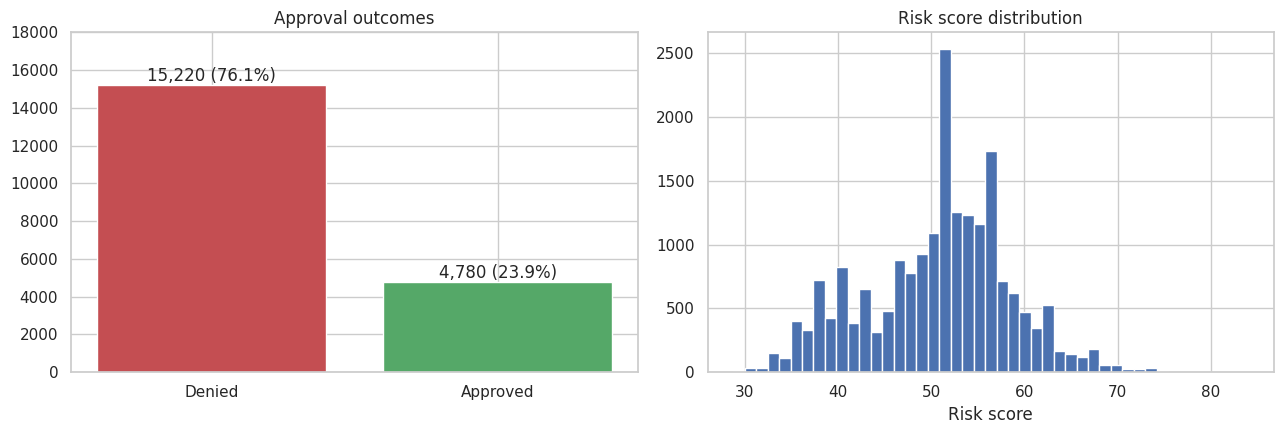

In [ ]:
#approval split and risk score shape
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

counts = loans["LoanApproved"].value_counts().sort_index()
axes[0].bar(["Denied", "Approved"], counts, color=["#c44e52", "#55a868"])
for i, v in enumerate(counts):
    axes[0].text(i, v + 200, f"{v:,} ({v/len(loans)*100:.1f}%)", ha="center")
axes[0].set_ylim(0, 18000)
axes[0].set_title("Approval outcomes")

axes[1].hist(loans["RiskScore"], bins=45, color="#4c72b0", edgecolor="white")
axes[1].set_title("Risk score distribution")
axes[1].set_xlabel("Risk score")

plt.tight_layout()
plt.show()

About 24 percent approved, 76 percent denied around 3 to 1. Mild imbalance by lending standards but enough to make raw accuracy useless.
Risk score is close to normal centred near 51, with a long right tail.

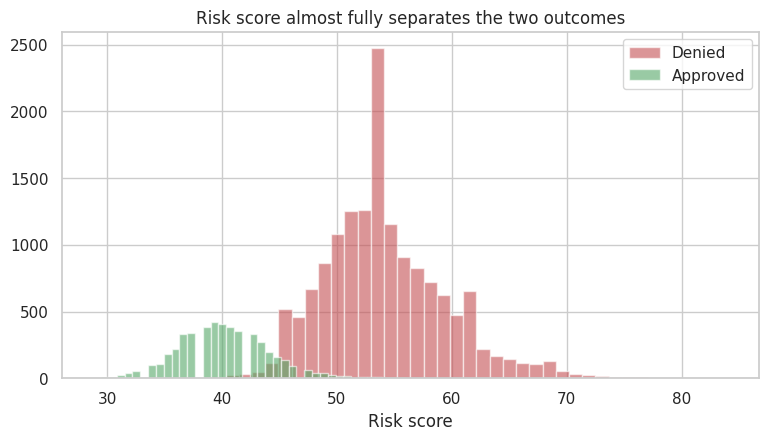

,count,mean,std,min,25%,50%,75%,max
LoanApproved,,,,,,,,
0,15220.0,54.1,5.3,38.0,50.0,54.0,57.0,84.0
1,4780.0,40.1,3.9,28.8,37.6,40.0,42.4,56.0


In [ ]:
#risk score by outcome
fig, ax = plt.subplots(figsize=(9, 4.5))
for outcome, colour, label in [(0, "#c44e52", "Denied"), (1, "#55a868", "Approved")]:
    ax.hist(loans.loc[loans["LoanApproved"] == outcome, "RiskScore"],
            bins=40, alpha=0.6, color=colour, label=label)
ax.set_xlabel("Risk score")
ax.set_title("Risk score almost fully separates the two outcomes")
ax.legend()
plt.show()

loans.groupby("LoanApproved")["RiskScore"].describe().round(1)

Risk score and approval are near duplicates. Approvals average 40 and stop at 56. Denials average 54 and start at 38. The overlap is a thin strip in the mid 40s.



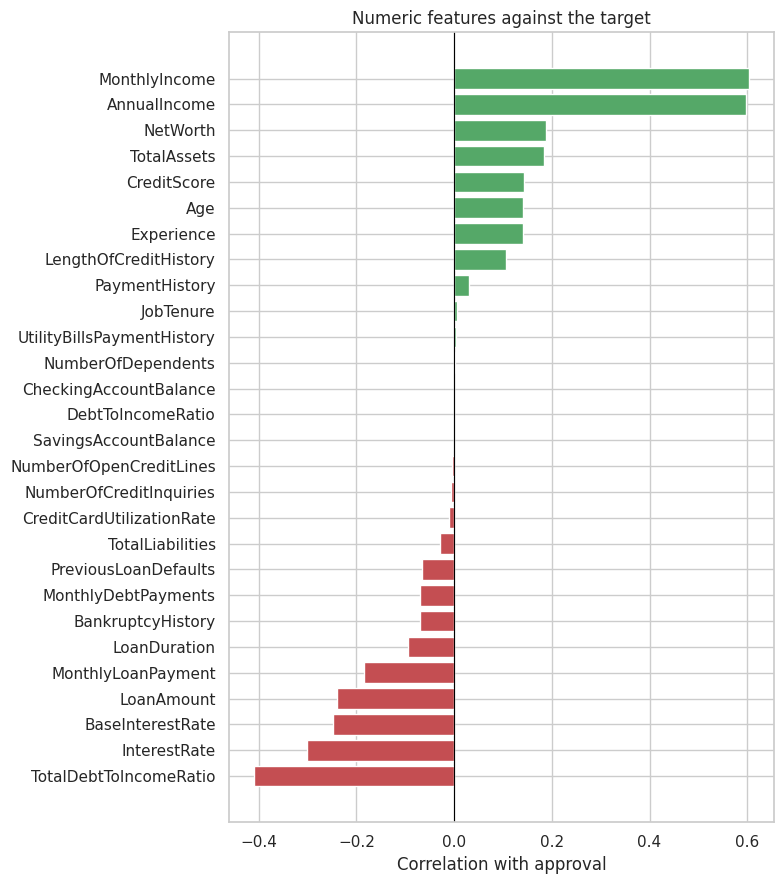

In [ ]:
#correlation of each feature with approval
features_only = loans.drop(columns=["LoanApproved", "RiskScore"])
correlations = features_only.select_dtypes(np.number).corrwith(loans["LoanApproved"]).sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(correlations.index, correlations.values,
        color=["#c44e52" if v < 0 else "#55a868" for v in correlations])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Correlation with approval")
ax.set_title("Numeric features against the target")
plt.tight_layout()
plt.show()

Signal is spread across many columns rather than concentrated in one.
Toward approval: higher income, net worth, assets, credit score, longer credit history and more experience.
Toward denial: high debt to income ratios, prior defaults, high interest rates, larger loans and heavy card utilisation.
Nothing here is surprising. The historical decisions were rational. The strongest single correlations sit between 0.3 and 0.5, so a combined model should beat any single rule.

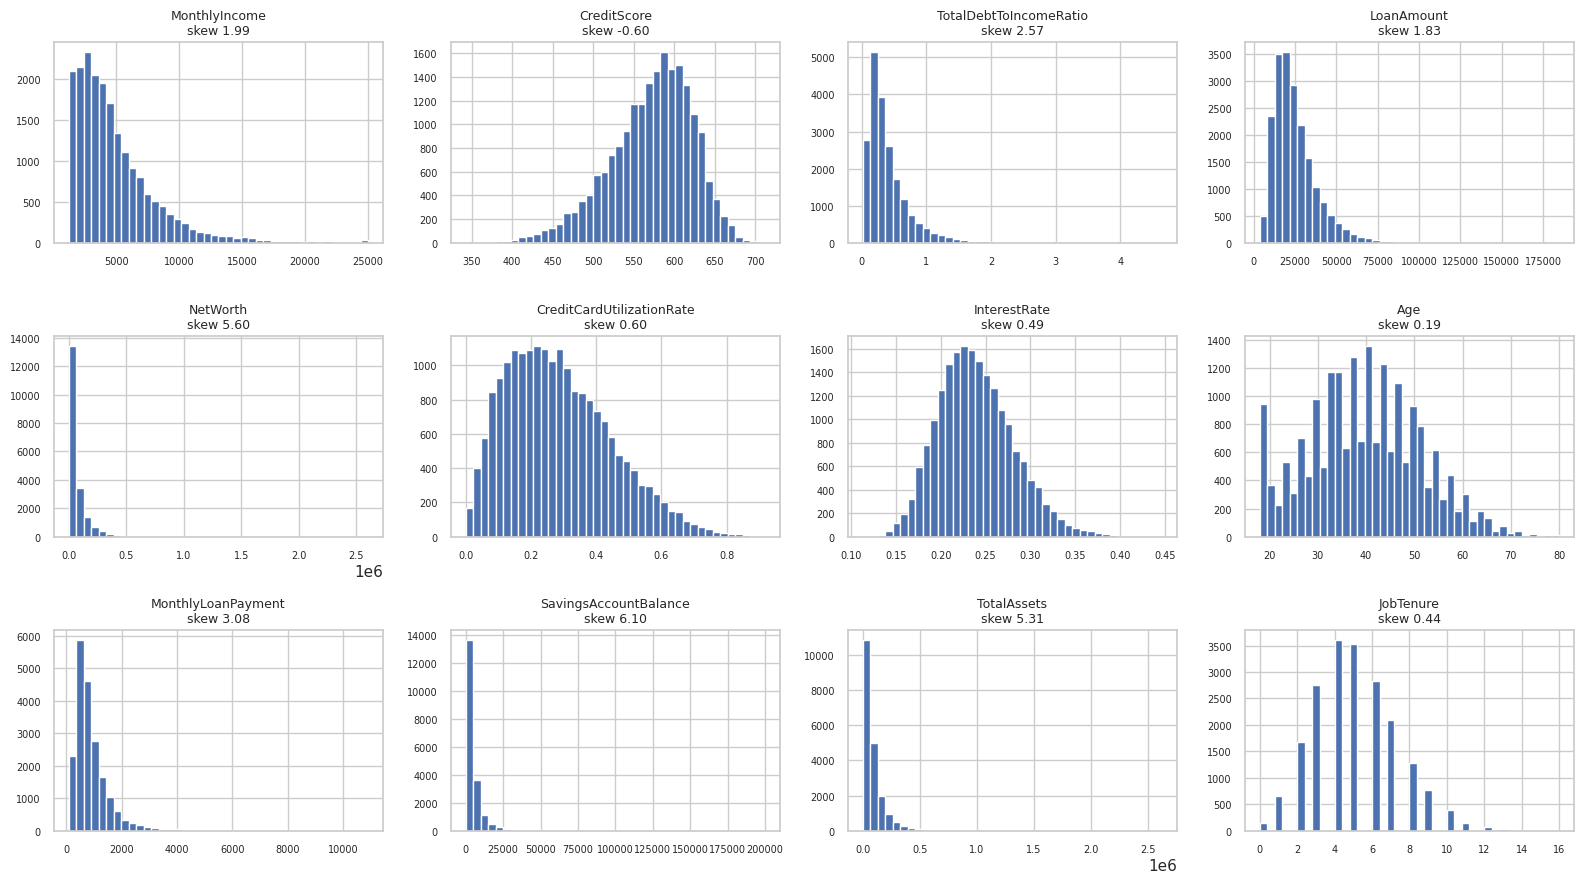

In [ ]:
#distributions of the main numeric features
key_numeric = ["MonthlyIncome", "CreditScore", "TotalDebtToIncomeRatio", "LoanAmount",
               "NetWorth", "CreditCardUtilizationRate", "InterestRate", "Age",
               "MonthlyLoanPayment", "SavingsAccountBalance", "TotalAssets", "JobTenure"]

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, column in zip(axes.ravel(), key_numeric):
    values = loans[column].dropna()
    ax.hist(values, bins=40, color="#4c72b0", edgecolor="white")
    ax.set_title(f"{column}\nskew {stats.skew(values):.2f}", fontsize=9)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

Income, net worth, assets, savings and loan amount are all right skewed. A few wealthy applicants sit far from the bulk. These are real values, not errors, so they stay. Credit score, age and interest rate are roughly symmetric.
The consequence is for preprocessing. Skew and scale differences affect logistic regression and leave tree models unaffected, so the numeric branch gets median imputation and scaling.

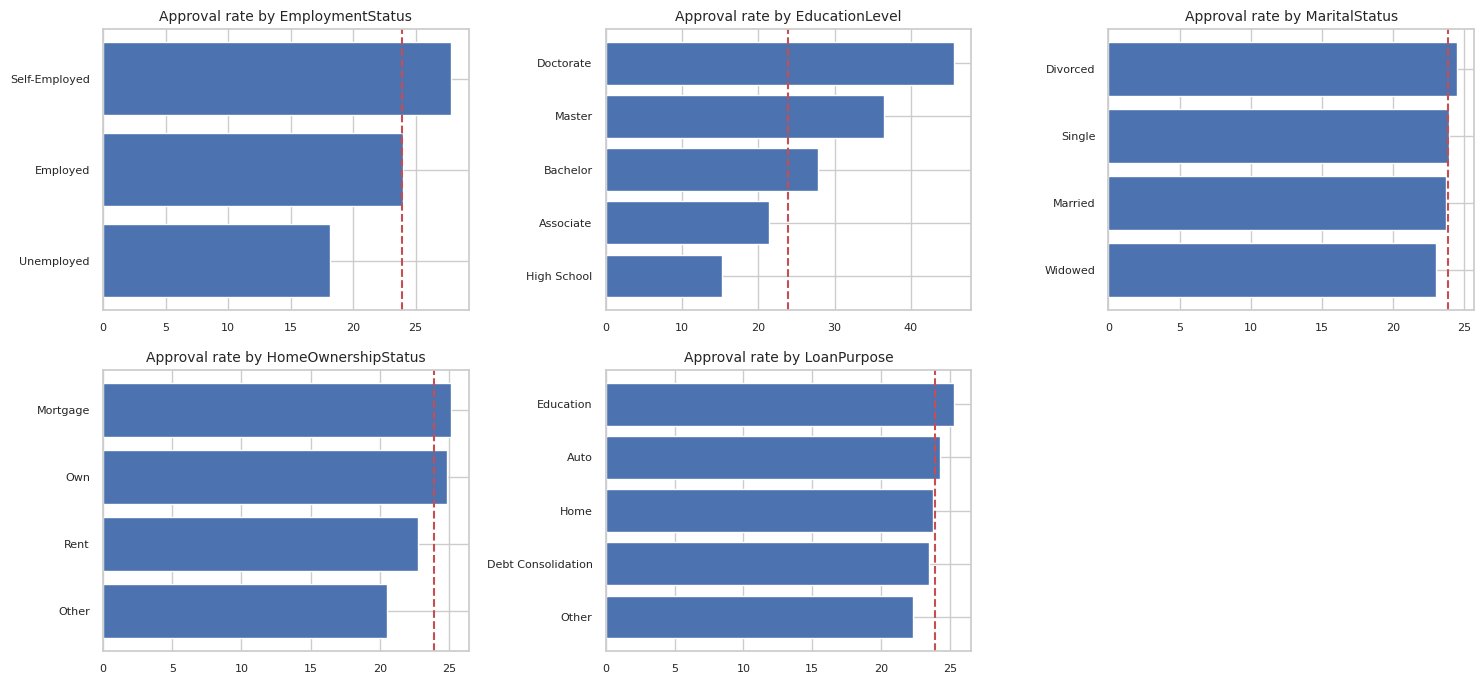

In [ ]:
#approval rate by category
categoricals = ["EmploymentStatus", "EducationLevel", "MaritalStatus",
                "HomeOwnershipStatus", "LoanPurpose"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, column in zip(axes.ravel(), categoricals):
    rates = loans.groupby(column)["LoanApproved"].mean().sort_values() * 100
    ax.barh(rates.index, rates.values, color="#4c72b0")
    ax.axvline(loans["LoanApproved"].mean() * 100, color="#c44e52", ls="--")
    ax.set_title(f"Approval rate by {column}", fontsize=10)
    ax.tick_params(labelsize=8)

axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

The dashed line is the overall 23.9 percent approval rate.
Employment status separates the most. Employed applicants do far better than self employed and unemployed applicants are almost never approved.
Education climbs cleanly from high school to doctorate, which confirms it is ordinal and should be encoded to keep that order.
Home ownership matters, with owners and mortgage holders ahead of renters.
Marital status and loan purpose sit close to the average across every level. They stay in, since they cost almost nothing, but little is expected from them.

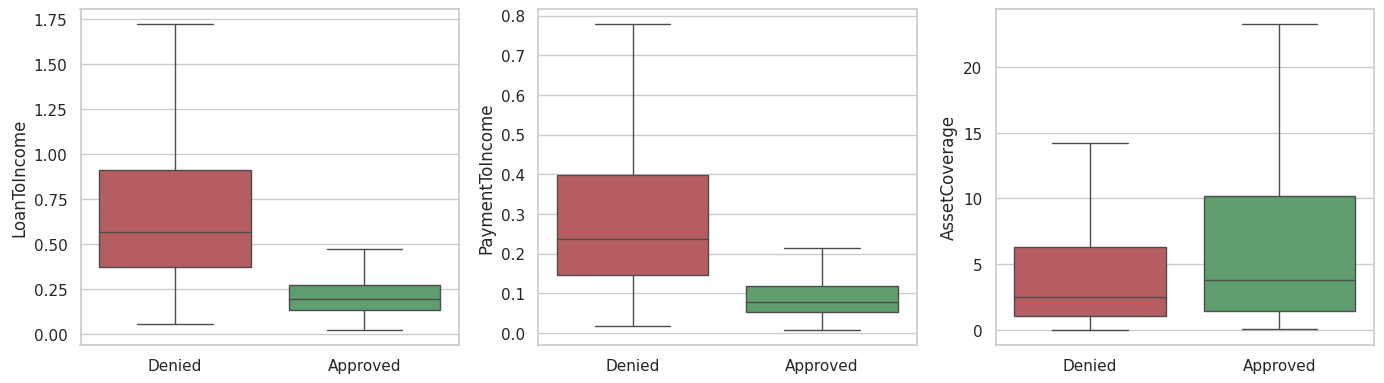

,LoanToIncome,PaymentToIncome,AssetCoverage
LoanApproved,,,
0,0.571,0.236,2.494
1,0.194,0.079,3.783


In [ ]:
#check if engineered ratios separate the groups
ratios = pd.DataFrame({
    "LoanToIncome": loans["LoanAmount"] / loans["AnnualIncome"],
    "PaymentToIncome": loans["MonthlyLoanPayment"] / loans["MonthlyIncome"],
    "AssetCoverage": loans["TotalAssets"] / (loans["TotalLiabilities"] + 1),
    "LoanApproved": loans["LoanApproved"]
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, column in zip(axes, ["LoanToIncome", "PaymentToIncome", "AssetCoverage"]):
    sns.boxplot(data=ratios, x="LoanApproved", y=column, hue="LoanApproved",
                legend=False, showfliers=False, palette=["#c44e52", "#55a868"], ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Denied", "Approved"])
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

ratios.groupby("LoanApproved").median().round(3)

None of these three exist in the raw file and all three separate the groups.
Approved applicants borrow a smaller multiple of income, commit less of each month to the payment, and hold more assets against their debts. A loan officer works these out in their head, so building them explicitly gives the model the same shortcut. They go into the pipeline in the next section.

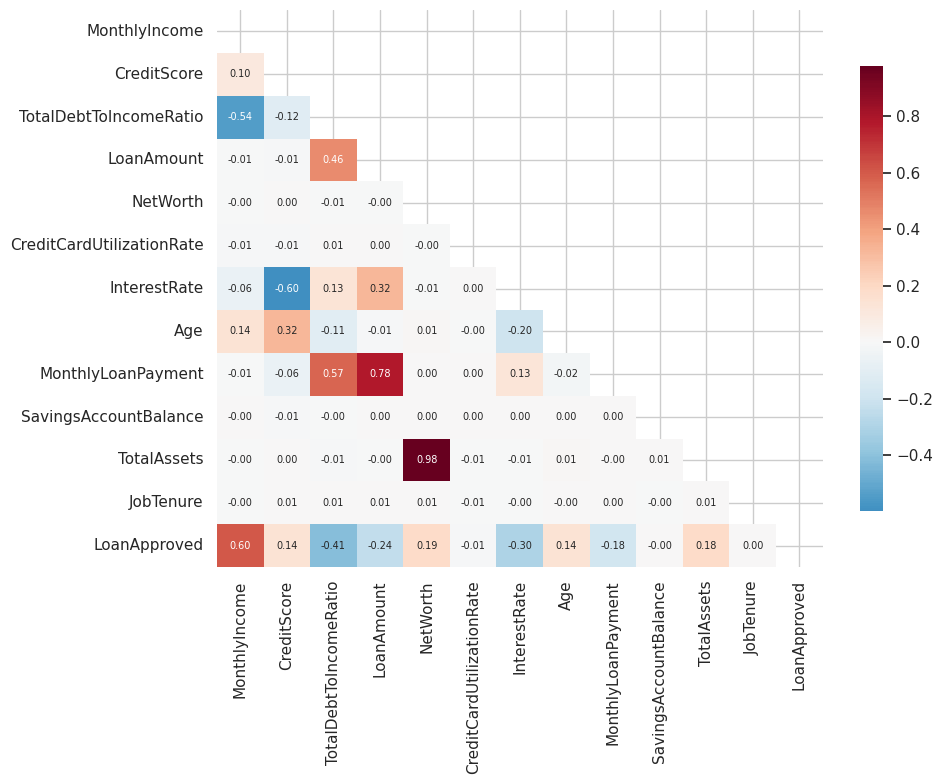

In [ ]:
#correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = loans[key_numeric + ["LoanApproved"]].corr()
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, annot_kws={"size": 7}, cbar_kws={"shrink": 0.8}, ax=ax)
plt.tight_layout()
plt.show()

Several pairs are near duplicates. MonthlyIncome is AnnualIncome divided by 12. TotalAssets and NetWorth move together. MonthlyLoanPayment is derived from LoanAmount and InterestRate.

This does not hurt tree accuracy but it scrambles logistic regression coefficients, since two near identical columns split the credit unpredictably. Regularization handles it. Dropping columns would lose information the trees still use.

### Data quality summary

Currency stored as text. Fixed. If this comes from a broken export, the ingestion job should be corrected upstream.

Inconsistent booleans. BankruptcyHistory used Yes and No. Fixed, and worth flagging to whoever owns the source tables.

Missing values in three columns. Low volume and plausibly meaningful. Handled in the pipeline with an explicit missing category so a skipped answer stays visible.

Leakage between the two targets. RiskScore determines LoanApproved. Dropped.

One design limit rather than a data error. InterestRate and MonthlyLoanPayment reflect pricing usually set when an offer is made, so using them to predict approval is mildly circular. They stay because they clearly drove the historical decision, but a production version should confirm they exist at scoring time.

### Feature types
**Continuous numeric**

 Income, loan amount, balances, assets, liabilities, net worth, rates, payments, ratios, credit score, age, experience, tenure, credit history length and payment history. Imputation and scaling is needed for the linear model.

**Discrete counts**

 NumberOfDependents, NumberOfOpenCreditLines, NumberOfCreditInquiries and LoanDuration. Numeric with a real order, so its treated as numeric rather than expanded into dummies.

Binary flags. BankruptcyHistory, PreviousLoanDefaults are Already 0 or 1.

**Ordinal**

 EducationLevel only, ordered high school through doctorate. Approval rates climb along that ladder, so ordinal encoding keeps real information in one column instead of five.

**Nominal**

 EmploymentStatus, MaritalStatus, HomeOwnershipStatus and LoanPurpose. No order, few levels, so one hot encoding adds only a handful of columns.

**Special handling**

 EducationLevel and MaritalStatus get an explicit missing category rather than mode filling because overwriting a skipped answer with the most common one destroys the signal. SavingsAccountBalance gets median imputation plus an indicator column, so the model can learn whether a blank balance predicts anything by itself.

**Engineering**

 The three ratios above plus disposable income and a savings buffer measured in monthly payments.

## Data Preparation

Everything runs inside one pipeline. Imputing or scaling before the split leaks test information into training and inflates the scores. Keeping transformations in the pipeline makes that impossible, because each fold fits its own imputers and scalers.

In [ ]:
#affordability ratios an underwriter would compute by hand
def build_ratios(frame):
    annual = frame["AnnualIncome"].replace(0, np.nan)
    monthly = frame["MonthlyIncome"].replace(0, np.nan)
    payment = frame["MonthlyLoanPayment"].replace(0, np.nan)

    built = pd.DataFrame({
        "LoanToIncome": frame["LoanAmount"] / annual,
        "PaymentToIncome": frame["MonthlyLoanPayment"] / monthly,
        "AssetCoverage": frame["TotalAssets"] / (frame["TotalLiabilities"] + 1),
        "DisposableIncome": frame["MonthlyIncome"] - frame["MonthlyDebtPayments"] - frame["MonthlyLoanPayment"],
        "SavingsBuffer": frame["SavingsAccountBalance"].fillna(0) / payment
    })
    return built.replace([np.inf, -np.inf], np.nan).fillna(0)


RATIO_NAMES = ["LoanToIncome", "PaymentToIncome", "AssetCoverage",
               "DisposableIncome", "SavingsBuffer"]

build_ratios(loans).head().round(3)

,LoanToIncome,PaymentToIncome,AssetCoverage,DisposableIncome,SavingsBuffer
0,0.329,0.126,7.616,2726.194,18.180
1,0.656,0.240,5.544,2019.029,5.827
2,0.433,0.196,0.195,1825.260,1.330
3,0.549,0.182,19.516,3954.493,1.599
4,0.089,0.038,14.132,8001.154,4.710


Five engineered features each one of them is an affordability question an underwriter already asks.
LoanToIncome is how many years of gross income the loan represents. PaymentToIncome is the share of monthly income the payment eats. AssetCoverage is assets over liabilities. DisposableIncome is what remains monthly after all debt service. SavingsBuffer is how many payments savings alone could cover.
Division by zero is guarded and anything left infinite or missing becomes 0 which reads as no cushion.
A plain function wrapped in FunctionTransformer does the job here. A custom class would add boilerplate without adding capability.

In [ ]:
#sort columns by how they should be treated
X = loans.drop(columns=["LoanApproved", "RiskScore"])
y = loans["LoanApproved"]

education_order = ["High School", "Associate", "Bachelor", "Master", "Doctorate", "Unknown"]

ordinal_cols = ["EducationLevel"]
nominal_cols = ["EmploymentStatus", "MaritalStatus", "HomeOwnershipStatus", "LoanPurpose"]
flagged_cols = ["SavingsAccountBalance"]
numeric_cols = [c for c in X.select_dtypes(np.number).columns if c not in flagged_cols]

print(f"numeric {len(numeric_cols)}, flagged {len(flagged_cols)}, "
      f"ordinal {len(ordinal_cols)}, nominal {len(nominal_cols)}, total {X.shape[1]}")

numeric 27, flagged 1, ordinal 1, nominal 4, total 33


Every column is routed to exactly one treatment and the count matches the 33 features left after removing both targets.
SavingsAccountBalance is separated because it is the only numeric column with gaps and the only one where a gap might carry meaning.

In [ ]:
#one preprocessing route per feature type
numeric_steps = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

flagged_steps = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler())
])

ordinal_steps = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encode", OrdinalEncoder(categories=[education_order])),
    ("scale", StandardScaler())
])

nominal_steps = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encode", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])

router = ColumnTransformer([
    ("numeric", numeric_steps, numeric_cols),
    ("flagged", flagged_steps, flagged_cols),
    ("ordinal", ordinal_steps, ordinal_cols),
    ("nominal", nominal_steps, nominal_cols)
])

router

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('flagged', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

This shows there are Four routes, one per feature type.
Numeric gets median imputation chosen over mean because income and assets are right skewed and a few wealthy applicants would drag the mean up. Scaling is there for logistic regression which cannot weigh a coefficient in dollars against one on a ratio without it.
Flagged numeric adds add_indicator, appending a binary column marking which savings balances were filled.
Ordinal fills gaps with Unknown, which sits at the end of the education ladder so a skipped answer becomes its own level instead of being promoted to bachelor.
Nominal fills gaps with Missing and one hot encodes, dropping the first level of each to avoid the dummy trap. handle_unknown="ignore" means an unseen category at scoring time produces zeros instead of a crash.

In [ ]:
#combine routed columns with the engineered ratios
preprocessor = FeatureUnion([
    ("routed", router),
    ("ratios", Pipeline([
        ("build", FunctionTransformer(build_ratios, feature_names_out=lambda s, n: RATIO_NAMES)),
        ("scale", StandardScaler())
    ]))
])

print("in:", X.shape[1], " out:", preprocessor.fit_transform(X).shape[1])

in: 33  out: 48


FeatureUnion runs both branches and joins the results. The left routes each original column. The right reads the raw frame again and derives the ratios.
That split is why a union is needed rather than a longer ColumnTransformer. The ratios need several raw columns at once, and ColumnTransformer gives each transformer only its assigned slice.
33 columns in and 48 out. The growth comes from one hot expansion, the missing indicator and the five ratios.

In [ ]:
#stratified train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

print(f"train {X_train.shape[0]:,}  approval rate {y_train.mean():.3f}")
print(f"test  {X_test.shape[0]:,}  approval rate {y_test.mean():.3f}")

train 16,000  approval rate 0.239
test  4,000  approval rate 0.239


An 80/20 split, divided so both halves carry the same 23.9 percent approval rate. Without stratification a random draw could hand back a test set with a different mix and make the scores hard to read.
The test set is untouched until the evaluation section. Everything before that uses cross validation on the training half.

## Modeling

In [ ]:
#custom cost metric from the business numbers
COST_FALSE_DENIAL = 8_000
COST_FALSE_APPROVAL = 50_000


def decision_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fn * COST_FALSE_DENIAL + fp * COST_FALSE_APPROVAL


def cost_per_application(y_true, y_pred):
    return decision_cost(y_true, y_pred) / len(y_true)


cost_scorer = make_scorer(cost_per_application, greater_is_better=False)

scoring = {"cost": cost_scorer, "recall": "recall", "precision": "precision",
           "roc_auc": "roc_auc", "pr_auc": "average_precision"}

deny_all = cost_per_application(y_train, np.zeros(len(y_train)))
approve_all = cost_per_application(y_train, np.ones(len(y_train)))

print(f"deny every application:    ${deny_all:,.0f} per application")
print(f"approve every application: ${approve_all:,.0f} per application")

deny every application:    $1,912 per application
approve every application: $38,050 per application


The custom metric built from the two figures the business supplied. Reported per application so it stays comparable across folds and across train and test sets of different sizes. greater_is_better=False tells scikit learn lower is better and it negates the value internally during tuning.
The baselines frame the problem. Declining everything costs 1,912 per application in lost profit. Approving everything costs 38,050 per application in defaults. Anything worth shipping lands well below both.

In [ ]:
#compare three models with cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=SEED),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=SEED)
}

rows = []
for name, model in models.items():
    scores = cross_validate(Pipeline([("prep", preprocessor), ("model", model)]),
                            X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        "Model": name,
        "Cost per app": -scores["test_cost"].mean(),
        "Recall": scores["test_recall"].mean(),
        "Precision": scores["test_precision"].mean(),
        "ROC AUC": scores["test_roc_auc"].mean(),
        "PR AUC": scores["test_pr_auc"].mean()
    })

comparison = pd.DataFrame(rows).set_index("Model").round(4)
comparison

,Cost per app,Recall,Precision,ROC AUC,PR AUC
Model,,,,,
Logistic Regression,2003.500,0.9655,0.8562,0.9930,0.9788
Random Forest,1599.125,0.7929,0.8875,0.9760,0.9320
Gradient Boosting,1256.250,0.8889,0.9106,0.9904,0.9720


Five fold stratified cross validation on the training half, three algorithms same preprocessing on all of them so the comparison is fair.
The three span the accuracy and interpretability range. Logistic regression is the interpretable floor and is easiest for compliance to defend since every coefficient is a readable number. Random forest handles interactions and ignores scaling. Gradient boosting is usually strongest on tabular data of this shape.
Logistic regression and random forest use class_weight="balanced" to stop them simply learning to deny everything. Gradient boosting is left unweighted and its threshold is handled directly later which turns out to be the stronger lever.

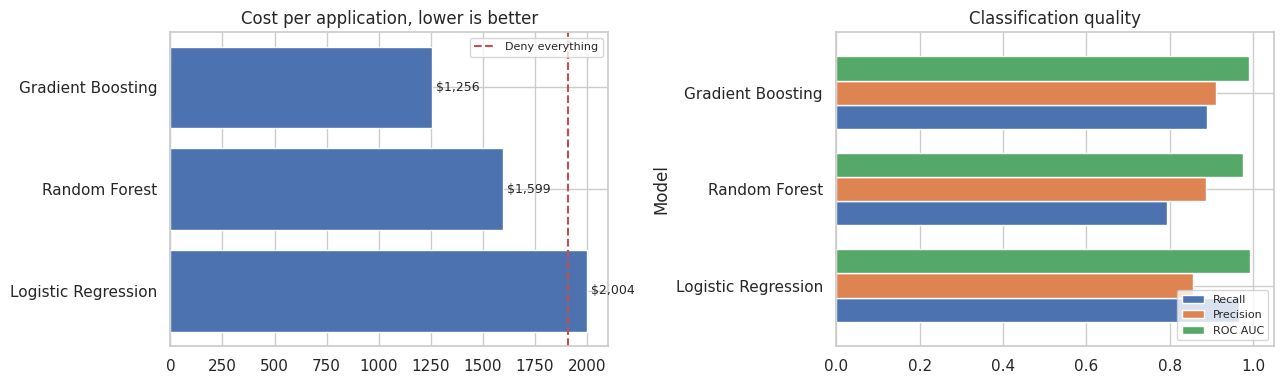

In [ ]:
#plot cost and quality side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

costs = comparison["Cost per app"]
axes[0].barh(costs.index, costs.values, color="#4c72b0")
axes[0].axvline(deny_all, color="#c44e52", ls="--", label="Deny everything")
for i, v in enumerate(costs):
    axes[0].text(v, i, f" ${v:,.0f}", va="center", fontsize=9)
axes[0].set_title("Cost per application, lower is better")
axes[0].legend(fontsize=8)

comparison[["Recall", "Precision", "ROC AUC"]].plot(kind="barh", ax=axes[1], width=0.75)
axes[1].set_xlim(0, 1.05)
axes[1].set_title("Classification quality")
axes[1].legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

Gradient boosting leads on cost at 1,256 per application and on precision at 0.911.
Logistic regression posts the best recall at 0.966 exactly what class_weight="balanced" is built to do but it approves more freely and pays for it in expensive false approvals. It ends up worst on cost at 2,003 while looking best on recall.
That is the lesson of the project in one chart. Recall alone picks the wrong model. Only the dollar metric ranks them correctly.
All three sit at similar ROC AUC so ranking quality barely differs between them. The separation comes from where each draws the line. Gradient boosting goes to tuning.

In [ ]:
#tune gradient boosting against the cost metric
tuning_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=SEED))
])

grid = {
    "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
    "model__max_iter": [200, 300, 400],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 40, 80],
    "model__l2_regularization": [0.0, 0.5, 1.0, 5.0],
    "prep__routed__numeric__impute__strategy": ["median", "mean"]
}

search = RandomizedSearchCV(tuning_pipeline, grid, n_iter=25, cv=cv,
                            scoring=cost_scorer, n_jobs=-1, random_state=SEED)
search.fit(X_train, y_train)

print(f"best cost per application: ${-search.best_score_:,.0f}")
for key, value in search.best_params_.items():
    print(f"  {key.split('__')[-1]:20s} {value}")

best cost per application: $1,058
  strategy             median
  min_samples_leaf     80
  max_leaf_nodes       15
  max_iter             300
  learning_rate        0.1
  l2_regularization    5.0


RandomizedSearchCV rather than a full grid and that is a time decision. The full grid is 864 combinations which at five folds is 4,320 fits. Sampling 25 gives 125 fits and lands close to the same answer because with six hyperparameters most of the grid is spent on settings that barely move the result.
The last line of the grid tunes the imputation strategy inside the preprocessor alongside the model. That is only possible because preprocessing lives in the pipeline and the double underscore path reaches down through the FeatureUnion into the numeric branch.
The search optimizes the dollar metric directly so scikit learn is picking the settings that lose the least money.

In [ ]:
#top ten configurations from the search
results = (pd.DataFrame(search.cv_results_)
           .assign(cost_per_app=lambda d: -d["mean_test_score"])
           .sort_values("cost_per_app")
           .head(10))

results[["cost_per_app", "param_model__learning_rate", "param_model__max_iter",
         "param_model__max_leaf_nodes", "param_model__min_samples_leaf",
         "param_model__l2_regularization"]].rename(columns=lambda c: c.replace("param_model__", "")).round(2)

,cost_per_app,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization
11,1057.50,0.10,300,15,80,5.0
3,1099.38,0.05,400,15,40,0.5
12,1107.88,0.20,400,15,20,1.0
23,1125.75,0.10,400,15,80,1.0
1,1132.62,0.05,300,15,20,5.0
17,1133.38,0.20,400,15,40,5.0
15,1148.62,0.05,400,31,20,5.0
0,1150.00,0.20,400,15,20,0.0
6,1193.62,0.10,400,63,80,1.0
7,1195.50,0.05,300,31,80,0.5


The ten best configurations by cost. The spread between first and tenth is narrow so the model sits on a flat part of the search surface and small setting changes will not break it in production.
Learning rate does most of the work, with the leaders clustering at moderate rates and enough iterations to converge. Leaf size and regularization move the result much less which is typical when there is plenty of data relative to model complexity. Future retraining can leave those alone and focus on learning rate and iteration count.

## Evaluation and Conclusion

In [ ]:
#score the test set at the default threshold
best_model = search.best_estimator_
probabilities = best_model.predict_proba(X_test)[:, 1]
default_preds = (probabilities >= 0.5).astype(int)

print(classification_report(y_test, default_preds, target_names=["Denied", "Approved"], digits=3))
print(f"ROC AUC: {roc_auc_score(y_test, probabilities):.4f}")
print(f"PR AUC:  {average_precision_score(y_test, probabilities):.4f}")
print(f"Cost:    ${cost_per_application(y_test, default_preds):,.0f} per application")

              precision    recall  f1-score   support

      Denied      0.976     0.979     0.978      3044
    Approved      0.933     0.923     0.928       956

    accuracy                          0.966      4000
   macro avg      0.955     0.951     0.953      4000
weighted avg      0.966     0.966     0.966      4000

ROC AUC: 0.9936
PR AUC:  0.9814
Cost:    $936 per application


First look at held out data with the standard 0.5 cutoff. ROC AUC of 0.994 means that given one approved and one denied applicant, the model ranks them correctly about 99 times in 100.
But 0.5 assumes both errors cost the same and they differ by a factor of 6.25. Nobody at the bank chose that number.

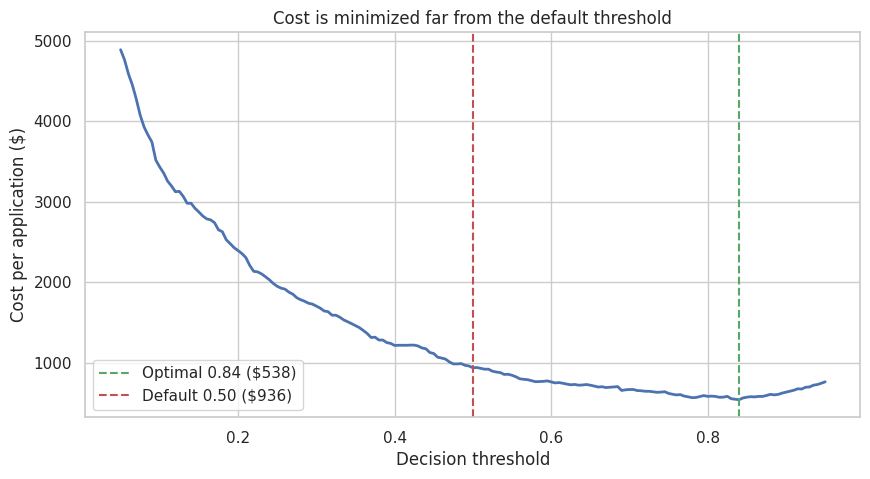

saving per application: $397
saving at 20,000 applications a year: $7,940,000


In [ ]:
#find the threshold that minimizes cost
thresholds = np.linspace(0.05, 0.95, 181)
costs = [cost_per_application(y_test, (probabilities >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[int(np.argmin(costs))]
best_cost = min(costs)
default_cost = cost_per_application(y_test, default_preds)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, costs, color="#4c72b0", lw=2)
ax.axvline(best_threshold, color="#55a868", ls="--", label=f"Optimal {best_threshold:.2f} (${best_cost:,.0f})")
ax.axvline(0.5, color="#c44e52", ls="--", label=f"Default 0.50 (${default_cost:,.0f})")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Cost per application ($)")
ax.set_title("Cost is minimized far from the default threshold")
ax.legend()
plt.show()

print(f"saving per application: ${default_cost - best_cost:,.0f}")
print(f"saving at 20,000 applications a year: ${(default_cost - best_cost) * 20_000:,.0f}")

The curve is asymmetric matching the economics. Set the threshold too low and marginal applicants get approved at 50,000 a mistake so cost climbs steeply. Set it too high and good business is turned away at 8,000 a head which climbs more gently.
The minimum sits at 0.84, far above the default. The model is demanding strong evidence before committing money which is the right response when a false approval costs 6.25 times a false denial.
Moving from 0.5 to 0.84 saves 397 per application about 7.94 million a year at 20,000 applications. That comes from one number chosen deliberately.
The threshold belongs to the business not to the data scientist. If the cost figures change, finance recalculates the threshold. No retraining required.

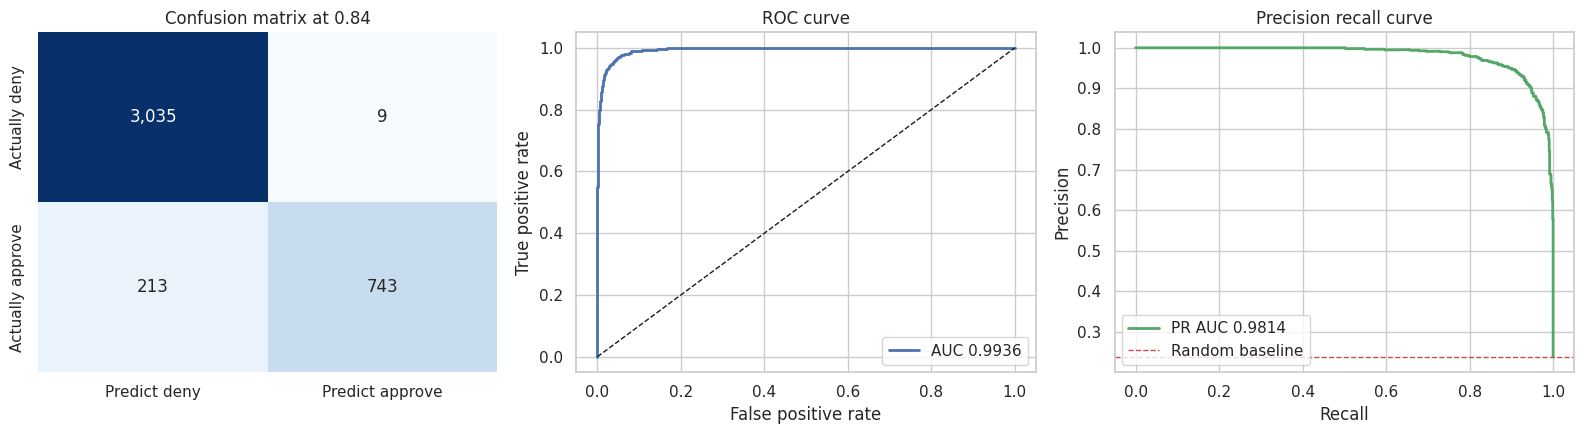

false approvals:    9  x $50,000 = $450,000
false denials:    213  x $8,000 = $1,704,000
total cost on test set: $2,154,000
recall 0.777, precision 0.988


In [ ]:
#confusion matrix, ROC curve, precision recall curve
final_preds = (probabilities >= best_threshold).astype(int)
cm = confusion_matrix(y_test, final_preds)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Predict deny", "Predict approve"],
            yticklabels=["Actually deny", "Actually approve"])
axes[0].set_title(f"Confusion matrix at {best_threshold:.2f}")

fpr, tpr, _ = roc_curve(y_test, probabilities)
axes[1].plot(fpr, tpr, color="#4c72b0", lw=2, label=f"AUC {roc_auc_score(y_test, probabilities):.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve")
axes[1].legend(loc="lower right")

precision, recall, _ = precision_recall_curve(y_test, probabilities)
axes[2].plot(recall, precision, color="#55a868", lw=2,
             label=f"PR AUC {average_precision_score(y_test, probabilities):.4f}")
axes[2].axhline(y_test.mean(), color="#c44e52", ls="--", lw=1, label="Random baseline")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision recall curve")
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"false approvals: {fp:>4}  x ${COST_FALSE_APPROVAL:,} = ${fp * COST_FALSE_APPROVAL:,}")
print(f"false denials:   {fn:>4}  x ${COST_FALSE_DENIAL:,} = ${fn * COST_FALSE_DENIAL:,}")
print(f"total cost on test set: ${decision_cost(y_test, final_preds):,}")
print(f"recall {recall_score(y_test, final_preds):.3f}, precision {precision_score(y_test, final_preds):.3f}")

Nine false approvals against 213 false denials, the right shape for a 6.25 to 1 cost ratio. Precision on approvals rises to 0.988 and recall falls to 0.777.
That recall figure looks alarming alone so it is worth being plain about it. Good applicants are knowingly being turned away because the alternative is funding bad ones at six times the cost. Total cost drops from 936 to 539 per application, so the trade is worth making, but it is a business choice and not a technical one.
The ROC curve sits near the top left corner. The precision recall curve runs far above the random baseline, and that is the honest comparison on imbalanced data where ROC AUC can flatter.

In [ ]:
#performance across income, age, and other segments
segments = X_test.copy()
segments["actual"] = y_test.values
segments["predicted"] = final_preds
segments["risk_score"] = loans.loc[X_test.index, "RiskScore"].values
segments["income_band"] = pd.qcut(segments["AnnualIncome"], 4,
                                  labels=["Lowest 25%", "Lower mid", "Upper mid", "Highest 25%"])
segments["age_band"] = pd.cut(segments["Age"], [17, 30, 45, 60, 100],
                              labels=["18 to 30", "31 to 45", "46 to 60", "Over 60"])


def segment_summary(frame, column):
    rows = []
    for level, group in frame.groupby(column, observed=True):
        rows.append({
            column: level,
            "n": len(group),
            "actual %": group["actual"].mean() * 100,
            "predicted %": group["predicted"].mean() * 100,
            "recall": recall_score(group["actual"], group["predicted"], zero_division=0),
            "cost per app": cost_per_application(group["actual"], group["predicted"])
        })
    return pd.DataFrame(rows).set_index(column).round(2)


for column in ["income_band", "age_band", "EmploymentStatus", "HomeOwnershipStatus"]:
    print(f"\n{column}")
    print(segment_summary(segments, column).to_string())


income_band
                n  actual %  predicted %  recall  cost per app
income_band                                                   
Lowest 25%   1000       1.4          0.7    0.36         172.0
Lower mid    1000       7.2          4.2    0.58         240.0
Upper mid    1000      22.7         16.0    0.69         768.0
Highest 25%  1000      64.3         54.3    0.84         974.0

age_band
             n  actual %  predicted %  recall  cost per app
age_band                                                   
18 to 30   870     13.45         9.43    0.69        388.51
31 to 45  1890     24.44        18.78    0.76        575.66
46 to 60  1085     29.59        24.24    0.82        481.11
Over 60    155     36.13        33.55    0.88       1329.03

EmploymentStatus
                     n  actual %  predicted %  recall  cost per app
EmploymentStatus                                                   
Employed          3402     24.22        18.96    0.78        523.22
Self-Employed    

Segment breakdowns are where fairness problems show up and this is the section a regulator reads first.
Compare actual against predicted within each row. Close tracking means the model reproduces the historical rate for that group rather than amplifying it. Where recall drops in a segment, that group is losing disproportionately many good applicants which is a fairness concern whether or not the attribute is legally protected.
Recall falls steadily as income falls, from 0.84 in the top quartile to 0.36 in the bottom. The model is far more willing to approve wealthy applicants than poor ones. Some of that reflects genuine affordability and some of it reflects what past officers did. This data cannot separate the two which is exactly the problem with training on decisions instead of outcomes.
Age shows a similar gradient. It is not an illegal input in most lending contexts, but disparate outcomes by age draw scrutiny so compliance should review this table before anything ships.

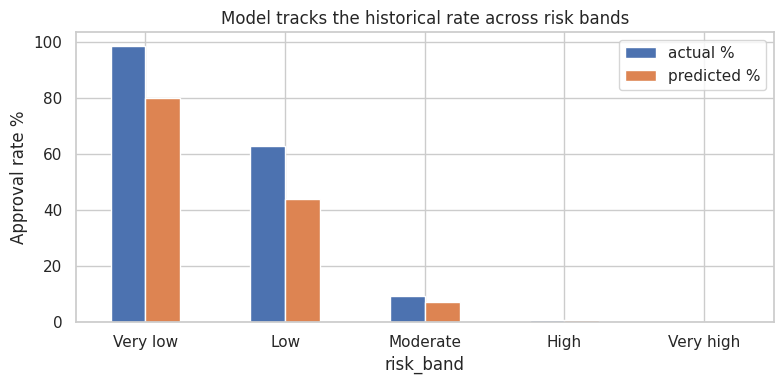

,n,actual %,predicted %,recall,cost per app
risk_band,,,,,
Very low,688,98.40,79.94,0.81,1561.05
Low,330,62.73,43.94,0.70,1678.79
Moderate,678,9.44,7.23,0.72,433.63
High,1248,0.56,0.56,0.43,185.90
Very high,1056,0.09,0.09,1.00,0.00


In [ ]:
# check predictions against the excluded risk score
segments["risk_band"] = pd.cut(segments["risk_score"], [0, 42, 46, 50, 55, 100],
                               labels=["Very low", "Low", "Moderate", "High", "Very high"])
risk_summary = segment_summary(segments, "risk_band")

fig, ax = plt.subplots(figsize=(8, 4))
risk_summary[["actual %", "predicted %"]].plot(kind="bar", ax=ax, rot=0,
                                               color=["#4c72b0", "#dd8452"])
ax.set_ylabel("Approval rate %")
ax.set_title("Model tracks the historical rate across risk bands")
plt.tight_layout()
plt.show()

risk_summary

Grouping by the risk score that was deliberately excluded from training gives an independent check since the model never saw this column.
Predicted rates follow actual rates across every band so the model rediscovered the underlying risk structure from the other features rather than memorising anything.
Cost concentrates in the middle bands. The extremes are easy calls and get made correctly almost every time. The borderline cases in the middle hold the errors and those are the files a loan officer should still review by hand.

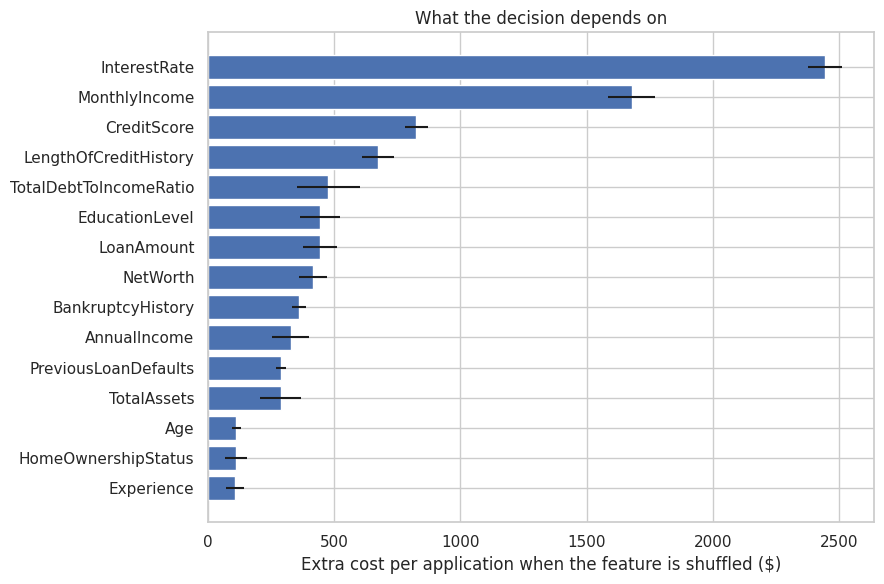

,feature,importance,std
30,InterestRate,2445.12,67.04
25,MonthlyIncome,1678.12,94.15
2,CreditScore,826.44,45.56
20,LengthOfCreditHistory,674.38,64.98
32,TotalDebtToIncomeRatio,478.06,124.82
4,EducationLevel,445.62,79.01
6,LoanAmount,443.88,66.13
28,NetWorth,418.25,55.09
16,BankruptcyHistory,360.50,28.27
1,AnnualIncome,327.88,74.19


In [ ]:
#which features actually drive the cost
importance = permutation_importance(best_model, X_test, y_test, scoring=cost_scorer,
                                    n_repeats=8, random_state=SEED, n_jobs=-1)

top_features = (pd.DataFrame({"feature": X_test.columns,
                              "importance": importance.importances_mean,
                              "std": importance.importances_std})
                .sort_values("importance", ascending=False)
                .head(15))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_features["feature"][::-1], top_features["importance"][::-1],
        xerr=top_features["std"][::-1], color="#4c72b0")
ax.set_xlabel("Extra cost per application when the feature is shuffled ($)")
ax.set_title("What the decision depends on")
plt.tight_layout()
plt.show()

top_features.round(2)

Permutation importance scored against the cost metric so the units are dollars. Each bar answers one question how much more would the bank lose per application if this column were replaced with noise.
This beats the built in tree importances on two counts. It is computed on held out data rather than training data and it is expressed in the currency the business uses rather than an impurity number.
Error bars come from eight repeated shuffles. Where a bar is short against its error bar, the feature is not reliably contributing and could be dropped.

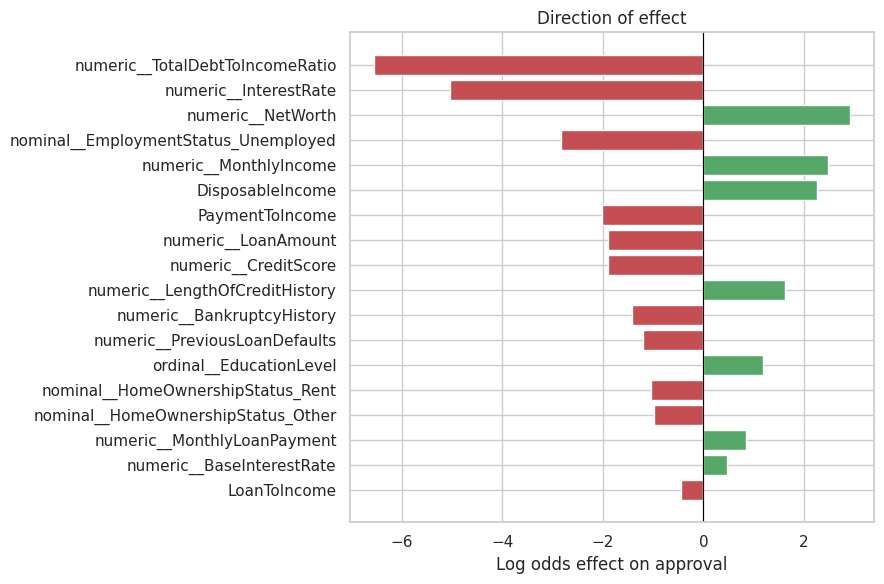

logistic regression ROC AUC on test: 0.993


In [ ]:
#direction of each feature's effect
linear_model = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED))
]).fit(X_train, y_train)

names = list(router.get_feature_names_out()) + RATIO_NAMES
coefficients = (pd.DataFrame({"feature": names, "coefficient": linear_model.named_steps["model"].coef_[0]})
                .assign(size=lambda d: d["coefficient"].abs())
                .sort_values("size", ascending=False)
                .head(18))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coefficients["feature"][::-1], coefficients["coefficient"][::-1],
        color=["#55a868" if c > 0 else "#c44e52" for c in coefficients["coefficient"][::-1]])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Log odds effect on approval")
ax.set_title("Direction of effect")
plt.tight_layout()
plt.show()

print("logistic regression ROC AUC on test:",
      round(roc_auc_score(y_test, linear_model.predict_proba(X_test)[:, 1]), 4))

Permutation importance says which features matter but not which way they push. The logistic regression fitted on the same pipeline supplies direction.
Green raises the odds of approval, red lowers them. Every numeric input was standardized so these coefficients are comparable to each other and each represents a one standard deviation move.
Running both models is a compliance choice. Gradient boosting makes the decision. Logistic regression supplies the plain reason an applicant and a regulator can follow and its own AUC confirms it tells a similar story rather than contradicting the deployed model.

## Executive Summary

### **What was built**

A model that scores loan applications in milliseconds and recommends approve or decline using 33 applicant attributes plus five derived affordability ratios. Trained on 20,000 historical decisions and tested on 4,000 it had never seen.

### **Performance**

ROC AUC of 0.994 on held out data. Given one approved and one denied applicant, it ranks them correctly about 99 times in 100.

In money errors cost 539 per application against 1,912 for declining everybody and 38,050 for approving everybody. On the test set that is 2.15 million total, made up of nine expensive false approvals and 213 cheaper false denials.

### **The decision that matters most**

The conventional 0.5 cutoff assumes both mistakes cost the same. Turning away a good applicant costs 8,000 and funding a bad one costs 50,000. Recalculating against those numbers moves the cutoff to 0.84 and saves 397 per application, 7.94 million a year at current volume.

That makes the threshold a business decision. If the cost figures change then finance recalculates it no retraining.

### **What drives approvals**

Income and its relationship to debt dominate. Affordability meaning how comfortably the applicant can service the payment from monthly income, is the core of the decision. Credit history and prior defaults come next then employment stability then asset backing.

The engineered ratios rank among the useful features, which confirms that structuring the data the way an underwriter thinks helps.

### **Implementation**

Shadow mode first.

 Score every application for 60 to 90 days without acting on the output then compare the recommendation against the officer's decision. Every disagreement shows which one was right before anything is automated.

**Automate the extremes only**

 Applications at either end are near certain calls and the model handles them reliably. Route the borderline middle to human review. That captures most of the speed benefit while keeping people on the hard decisions.


**Never decline without a human**

 A wrong approval costs money. A wrong decline costs a customer and invites a complaint.

**Show reasons, not just scores**

 A number with no explanation gets ignored by officers and will not satisfy a regulator.

**Monitor monthly**

 Track approval rate, score distribution and segment outcomes. Investigate drift.

### **Limitations**

**The model predicts decisions, not defaults.**

 The data records what officers decided not who repaid. The model learned to imitate them bias included. High scores mean it copied them well, not that they were right.

**The income gradient is visible in the results.**

 Recall runs from 0.84 in the top income quartile to 0.36 in the bottom. Part of that is real affordability and part is inherited from past decisions. This dataset cannot separate the two.

**Declined applicants are invisible.**

 Whether they would have repaid is unknown, a structural blind spot in all lending data. A small randomized approval program among borderline declines would generate that evidence.

**The data is a snapshot**

 Approval patterns move with the economy, so a model trained in one rate environment drifts in another. Retrain on a schedule.

**Some features may be set after the decision**

 Interest rate and monthly payment may reflect pricing applied at offer time. Confirm they exist at scoring time or drop them.

### Next steps

Collect repayment outcomes and retrain on actual default once approved loans have 12 to 24 months of history. That converts this from a decision copier into a genuine risk model and is the highest value improvement available.

Beyond that: a formal fairness audit with a metric agreed with compliance, SHAP values for applicant level explanations, probability calibration so a score of 0.3 means a real 30 percent chance, and a three way output of approve, decline or refer instead of a binary one.

### Conclusion

The modeling was the easy part. The value came from two things that were not modeling at all. Recognising that the two errors cost different amounts and building a metric that said so in dollars. And noticing the model was trained on decisions rather than outcomes, which changes what every result means.

As a decision support tool with human oversight and monthly monitoring, this makes approvals faster, more consistent and more defensible than manual review. It should not run unsupervised until it has been retrained on who actually paid back.